# Random Forest voor Rister Planning — Business Understanding

## Context

Rovecom Groep bouwt het Rister platform voor het plannen van servicetaken. Het systeem moet twee dingen doen:

1. **Tijdsvoorspelling** — hoe lang duurt een servicetaak?
2. **Medewerkerranking** — welke medewerker past het beste bij een taak?

Dit notebook bouwt de **Random Forest baseline**. Het is Model A in mijn vergelijkingsonderzoek. Ik gebruik geen Optuna tuning hier — het doel is een eerlijke ondergrens bepalen. Random Forest is snel, interpreteerbaar, en werkt goed uit de doos met redelijke hyperparameters.

## Aanpak

- **Model A (regressie)**: `RandomForestRegressor` op `REAL_WORKED_TIME`
- **Model B (ranking)**: `RandomForestRegressor` op `suitability_score` (pointwise), gesorteerd op predicted score
- **Encoding**: `OrdinalEncoder` voor categorische features (RF heeft geen native categorische support)
- **Geen Optuna**: vaste hyperparameters, dit is de baseline

## KPIs

| KPI | Doel |
|-----|------|
| MAE regressie | ≤ 0.5 uur (30 min) |
| NDCG@3 ranking | ≥ 0.80 |

**LightGBM referentie**: MAE 1.2490 uur, NDCG@3 0.5093

## Stap 1 — Imports

In [17]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import onnxruntime as ort
import pandas as pd
import sklearn
from mlflow.tracking import MlflowClient
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

print(f"scikit-learn: {sklearn.__version__}")
print(f"mlflow: {mlflow.__version__}")

scikit-learn: 1.8.0
mlflow: 3.10.1


## Stap 2 — MLflow configuratie

In [18]:
MLFLOW_TRACKING_URI = "http://127.0.0.1:5002"
MLFLOW_EXPERIMENT = "rister-random-forest-v1"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print(f"MLflow tracking: {mlflow.get_tracking_uri()}")
print(f"Experiment: {MLFLOW_EXPERIMENT}")

MLflow tracking: http://127.0.0.1:5002
Experiment: rister-random-forest-v1


## Stap 3 — Data laden

In [19]:
df = pd.read_csv("dataframe_gecombineerd.csv")

# Fix kolomnaam mismatch: CSV gebruikt 'aar' prefix
df.rename(columns={"aarURENVERANTW_MEDID": "URENVERANTW_MEDID"}, inplace=True)

print(f"Rijen: {len(df):,}, Kolommen: {len(df.columns)}")
df.head()

Rijen: 28,693, Kolommen: 41


/var/folders/7f/fy8dzxkx0c53qfwftx_w5p0m0000gr/T/ipykernel_11884/2084754077.py:1: DtypeWarning: Columns (0,1,3,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataframe_gecombineerd.csv")


,URENVERANTW_MEDID,DIENST_ART_ID,BEWERKING_ID,RELATIE_ID,DIENST_ART_OMS,MACH_OMS,REL_POSTCODE,lat,lon,URENVERANTW_DATUM,...,hoeveelheid_aanwezig,con,REAL_WORKED_TIME,bron,EquipmentGroupTypes,planninggroupsname,hoeveelheid_baal,norm_ervaring_bewerking,norm_klant_bezoeken,suitability_score
0,25,1634,NaN,4144.0,Aanvoer kranen (derden),NaN,2355AH,52.168026,4.580257,2015-01-16,...,1.0,15_poel,9.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
1,11,1043,NaN,4144.0,Aanvulzand (af Rook etc.),NaN,2355AH,52.168026,4.580257,2015-01-19,...,1.0,15_poel,3.0,werkxpert,NaN,NaN,NaN,0.0,0.052632,0.021053
2,30,1275,NaN,4312.0,Schelpen (afgehaald GP),NaN,2481KA,52.166547,4.603481,2015-01-23,...,1.0,15_poel,2.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
3,745,966,NaN,3072.0,PVC verloopr 110x125 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.000000,0.000000
4,745,947,NaN,3072.0,PVC oversch mof 110 SN4,NaN,2375AP,52.186199,4.587957,2015-01-29,...,1.0,15_poel,0.5,werkxpert,NaN,NaN,NaN,0.0,0.105263,0.042105


## Stap 4 — Features en targets

Ik gebruik dezelfde 11 categorische en 25 numerieke features als het LightGBM notebook — zodat de vergelijking eerlijk is.

In [20]:
CATEGORICAL = [
    "URENVERANTW_MEDID",
    "BEWERKING_ID",
    "DIENST_ART_ID",
    "RELATIE_ID",
    "REL_POSTCODE",
    "DIENST_ART_OMS",
    "MACH_OMS",
    "con",
    "bron",
    "EquipmentGroupTypes",
    "planninggroupsname",
]

NUMERICAL = [
    "lat",
    "lon",
    "dag_sin",
    "dag_cos",
    "maand_sin",
    "maand_cos",
    "week_sin",
    "week_cos",
    "med_std_tijd",
    "med_aantal_opdrachten",
    "med_ervaring_bewerking",
    "med_gem_tijd",
    "taak_gem",
    "med_klant_bezoeken",
    "med_klant_ratio",
    "med_klant_snelheid",
    "med_bewerking_snelheid",
    "med_klant_gem_tijd",
    "med_bewerking_gem_tijd",
    "med_totaal_opdrachten",
    "hoeveelheid_volume",
    "hoeveelheid_gewicht",
    "hoeveelheid_stuks",
    "hoeveelheid_aanwezig",
    "hoeveelheid_baal",
]

FEATURES = CATEGORICAL + NUMERICAL
TARGET_TIME = "REAL_WORKED_TIME"
TARGET_RANK = "suitability_score"

print(
    f"Features: {len(CATEGORICAL)} categorisch + {len(NUMERICAL)} numeriek = {len(FEATURES)} totaal"
)

Features: 11 categorisch + 25 numeriek = 36 totaal


## Stap 5 — Data voorbereiding

Random Forest heeft geen native categorische support zoals LightGBM. Ik gebruik `OrdinalEncoder` om categorische waarden om te zetten naar integers. `handle_unknown="use_encoded_value"` zorgt dat onbekende categorieën in validatie/inference niet crashen maar -1 krijgen.

In [21]:
# Fillna en type conversie
for col in CATEGORICAL:
    df[col] = df[col].fillna("ONBEKEND").astype(str)

for col in NUMERICAL:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print("Categorische cardinaliteiten:")
for col in CATEGORICAL:
    print(f"  {col:30s} → {df[col].nunique():5d}")

Categorische cardinaliteiten:
  URENVERANTW_MEDID              →   337
  BEWERKING_ID                   →    83
  DIENST_ART_ID                  →   524
  RELATIE_ID                     →  1686
  REL_POSTCODE                   →  1190
  DIENST_ART_OMS                 →   544
  MACH_OMS                       →   117
  con                            →    51
  bron                           →     2
  EquipmentGroupTypes            →     4
  planninggroupsname             →    20


## Stap 6 — Train/val split

80/20 split, `random_state=42`. De OrdinalEncoder fit ik op de traindata — zo voorkom ik data leakage.

In [22]:
train_idx, val_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42)

X_train = df.loc[train_idx, FEATURES].reset_index(drop=True)
X_val = df.loc[val_idx, FEATURES].reset_index(drop=True)

y_time_train = df.loc[train_idx, TARGET_TIME].values
y_time_val = df.loc[val_idx, TARGET_TIME].values
y_rank_train = df.loc[train_idx, TARGET_RANK].values
y_rank_val = df.loc[val_idx, TARGET_RANK].values

# OrdinalEncoder: fit op traindata
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
enc.fit(X_train[CATEGORICAL])

# Gecombineerde arrays: categorisch (encoded) + numeriek
X_train_rf = np.hstack([enc.transform(X_train[CATEGORICAL]), X_train[NUMERICAL].values]).astype(
    np.float32
)

X_val_rf = np.hstack([enc.transform(X_val[CATEGORICAL]), X_val[NUMERICAL].values]).astype(
    np.float32
)

print(f"Train: {len(train_idx):,}  |  Val: {len(val_idx):,}")
print(f"Feature matrix shape: {X_train_rf.shape}")

Train: 22,954  |  Val: 5,739
Feature matrix shape: (22954, 36)


## Stap 7 — Data verkennen

Ik kijk naar de verdeling van de twee targets.

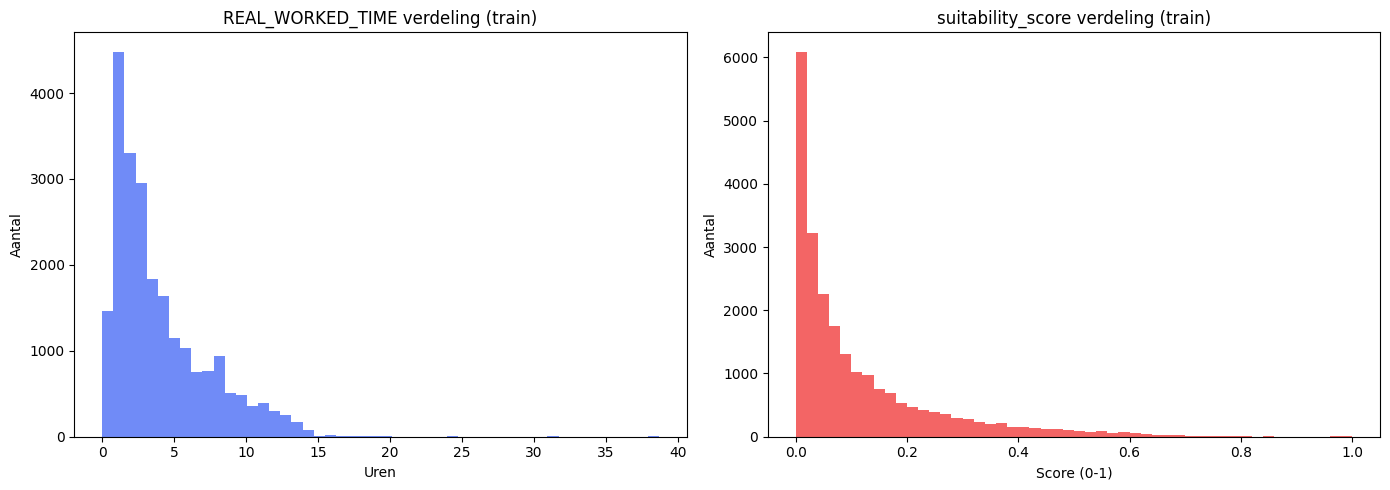

REAL_WORKED_TIME: gem=4.08u, mediaan=3.00u
suitability_score: gem=0.114, std=0.140


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_time_train, bins=50, color="#4c6ef5", alpha=0.8)
axes[0].set_title("REAL_WORKED_TIME verdeling (train)")
axes[0].set_xlabel("Uren")
axes[0].set_ylabel("Aantal")

axes[1].hist(y_rank_train, bins=50, color="#f03e3e", alpha=0.8)
axes[1].set_title("suitability_score verdeling (train)")
axes[1].set_xlabel("Score (0-1)")
axes[1].set_ylabel("Aantal")

plt.tight_layout()
plt.show()

print(f"REAL_WORKED_TIME: gem={y_time_train.mean():.2f}u, mediaan={np.median(y_time_train):.2f}u")
print(f"suitability_score: gem={y_rank_train.mean():.3f}, std={y_rank_train.std():.3f}")

## Stap 8 — Groepering voor ranking evaluatie

Ik zet de dataset op dezelfde manier klaar als in het LightGBM notebook — gesorteerd op `(con, BEWERKING_ID)` groepen. Zo kan ik NDCG@3 op dezelfde manier berekenen.

In [24]:
GROUP_COLS = ["con", "BEWERKING_ID"]

df["_group_key"] = df[GROUP_COLS].astype(str).agg("__".join, axis=1)

# Relevance labels: suitability_score → 0-4
bins = [-0.001, 0.2, 0.4, 0.6, 0.8, 1.001]
labels_int = [0, 1, 2, 3, 4]
df["_rank_label"] = pd.cut(df[TARGET_RANK], bins=bins, labels=labels_int).astype(int)

print("Relevance label verdeling:")
print(df["_rank_label"].value_counts().sort_index())

# Sorteer op groep
df_sorted = df.sort_values("_group_key").reset_index(drop=True)

# Split op groepniveau
group_keys = list(df_sorted.groupby("_group_key").groups.keys())
train_keys, val_keys = train_test_split(group_keys, test_size=0.2, random_state=42)
train_keys_set = set(train_keys)
val_keys_set = set(val_keys)

train_mask = df_sorted["_group_key"].isin(train_keys_set)
val_mask = df_sorted["_group_key"].isin(val_keys_set)

X_rank_train_df = df_sorted.loc[train_mask, CATEGORICAL + NUMERICAL]
X_rank_val_df = df_sorted.loc[val_mask, CATEGORICAL + NUMERICAL]

y_rank_train_float = df_sorted.loc[train_mask, TARGET_RANK].values
y_rank_val_float = df_sorted.loc[val_mask, TARGET_RANK].values

train_groups = df_sorted.loc[train_mask].groupby("_group_key").size().values
val_groups = df_sorted.loc[val_mask].groupby("_group_key").size().values

# Encode voor RF
X_rank_train_rf = np.hstack(
    [enc.transform(X_rank_train_df[CATEGORICAL].astype(str)), X_rank_train_df[NUMERICAL].values]
).astype(np.float32)

X_rank_val_rf = np.hstack(
    [enc.transform(X_rank_val_df[CATEGORICAL].astype(str)), X_rank_val_df[NUMERICAL].values]
).astype(np.float32)

print(f"\nRank train: {len(X_rank_train_rf):,} rijen in {len(train_groups):,} groepen")
print(f"Rank val:   {len(X_rank_val_rf):,} rijen in {len(val_groups):,} groepen")

Relevance label verdeling:
_rank_label
0    23299
1     3789
2     1257
3      303
4       45
Name: count, dtype: int64

Rank train: 20,918 rijen in 224 groepen
Rank val:   7,775 rijen in 56 groepen


## Stap 9 — Model A: Tijdsvoorspelling

Dit is de baseline, geen Optuna tuning. Het doel is een eerlijke ondergrens.

Parameters:
- `n_estimators=200` — genoeg bomen voor stabiele schattingen
- `max_features="sqrt"` — standaard voor regressie, voorkomt te gecorreleerde bomen
- `n_jobs=-1` — alle CPU cores

In [25]:
reg_model = RandomForestRegressor(
    n_estimators=200,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
reg_model.fit(X_train_rf, y_time_train)
print("Regressiemodel getraind.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.2s


Regressiemodel getraind.


[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    1.1s finished


## Stap 10 — Model B: Ranking (pointwise)

RF ondersteunt geen native LambdaRank zoals LightGBM. Ik gebruik een pointwise aanpak: ik train een RF op `suitability_score` en sorteer medewerkers op predicted score. Dit is een eerlijke vergelijking want ik gebruik dezelfde informatie.

In [26]:
rank_model = RandomForestRegressor(
    n_estimators=200,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)
rank_model.fit(X_rank_train_rf, y_rank_train_float)
print("Rankingmodel getraind.")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    4.3s


Rankingmodel getraind.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    4.7s finished


## Stap 11 — Evaluatie regressie

MAE, RMSE en R² op de validatieset. KPI: MAE ≤ 0.5 uur.

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


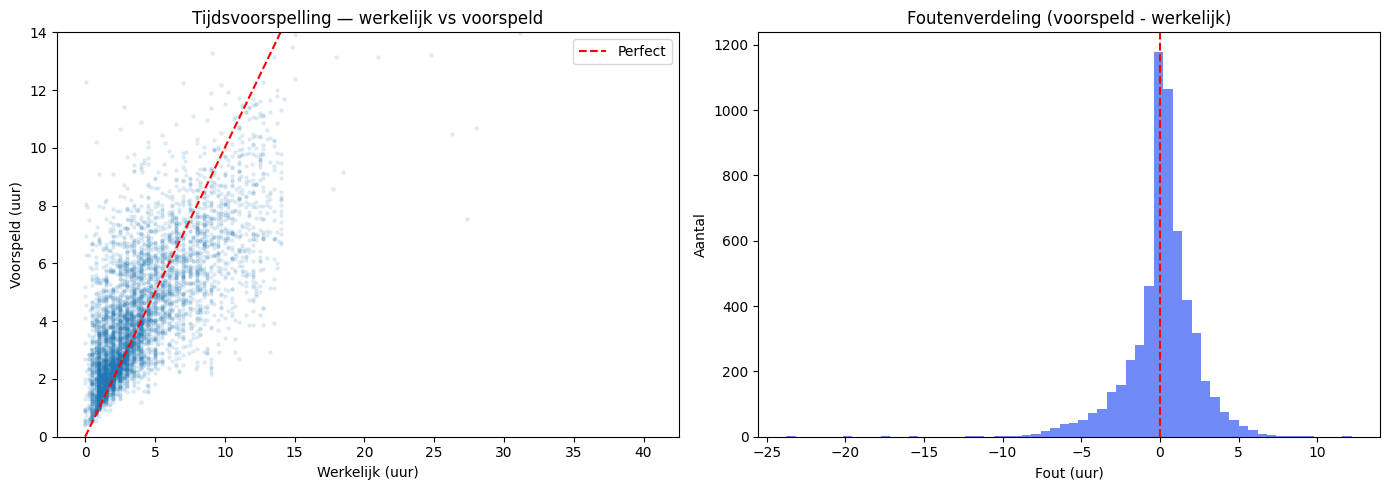

MAE:  1.4932 uur (89.6 min)
RMSE: 2.2055 uur (132.3 min)
R²:   0.5508
KPI:  MAE > 30 min ✗ (boven KPI)

Vergelijking LightGBM: MAE 1.2490 uur (+0.2442 uur)


In [27]:
y_pred_time = reg_model.predict(X_val_rf)

mae = mean_absolute_error(y_time_val, y_pred_time)
rmse = np.sqrt(mean_squared_error(y_time_val, y_pred_time))
r2 = r2_score(y_time_val, y_pred_time)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_time_val, y_pred_time, alpha=0.1, s=5)
axes[0].plot([0, y_time_val.max()], [0, y_time_val.max()], "r--", label="Perfect")
axes[0].set_xlabel("Werkelijk (uur)")
axes[0].set_ylabel("Voorspeld (uur)")
axes[0].set_ylim(0, 14)
axes[0].set_title("Tijdsvoorspelling — werkelijk vs voorspeld")
axes[0].legend()

errors = y_pred_time - y_time_val
axes[1].hist(errors, bins=60, color="#4c6ef5", alpha=0.8)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_title("Foutenverdeling (voorspeld - werkelijk)")
axes[1].set_xlabel("Fout (uur)")
axes[1].set_ylabel("Aantal")

plt.tight_layout()
plt.show()

print(f"MAE:  {mae:.4f} uur ({mae * 60:.1f} min)")
print(f"RMSE: {rmse:.4f} uur ({rmse * 60:.1f} min)")
print(f"R²:   {r2:.4f}")
print(f"KPI:  MAE {'<= 30 min ✓' if mae * 60 <= 30 else '> 30 min ✗ (boven KPI)'}")
print(
    f"\nVergelijking LightGBM: MAE 1.2490 uur ({'+' if mae > 1.2490 else '-'}{abs(mae - 1.2490):.4f} uur)"
)

### Interpretatie regressie resultaten

| Metric | Waarde | Betekenis |
|--------|--------|-----------|
| MAE | 1.4932 uur | Gemiddeld 90 minuten afwijking — boven de KPI van 30 min |
| RMSE | 2.2055 uur | Factor 1.48 t.o.v. MAE — uitschieters aanwezig |
| R² | 0.5508 | Het model verklaart 55% van de variantie |

De MAE van 1.49 uur is hoger dan LightGBM (1.25 uur, +0.24 uur verschil). Dit is verwacht: Random Forest is de baseline zonder hyperparameter-tuning. De R² is ook iets lager (0.55 vs 0.64). Het verschil tussen MAE en RMSE (factor 1.48) geeft aan dat er uitschieters zijn. Als baseline laat RF zien dat LightGBM meerwaarde biedt op regressie.

## Stap 12 — Evaluatie ranking

NDCG@3 en NDCG@5 per groep. KPI: NDCG@3 ≥ 0.80.

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


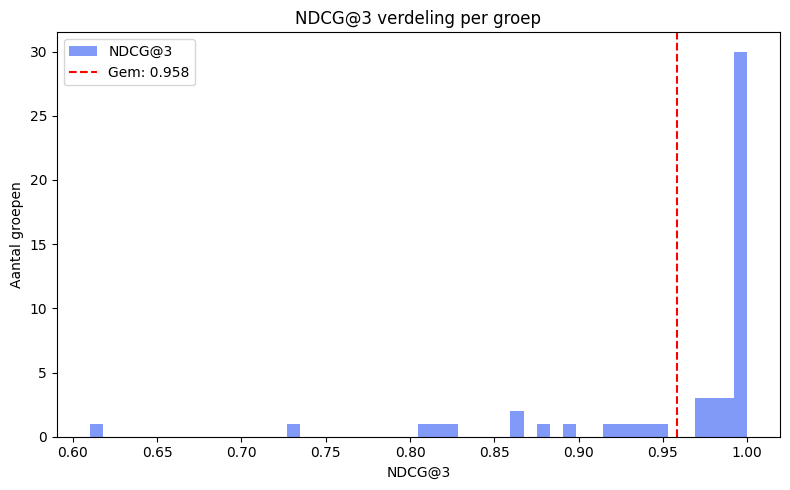

NDCG@3: 0.9582 (std: 0.0780)
NDCG@5: 0.9641 (std: 0.0629)
KPI:    NDCG@3 >= 0.80 ✓

Vergelijking LightGBM: NDCG@3 0.5093 (+0.4489)


In [28]:
y_pred_rank = rank_model.predict(X_rank_val_rf)

ndcg3_scores, ndcg5_scores = [], []
offset = 0
for size in val_groups:
    if size < 2:
        offset += size
        continue
    g_true = y_rank_val_float[offset : offset + size]
    g_pred = y_pred_rank[offset : offset + size]
    ndcg3_scores.append(ndcg_score([g_true], [g_pred], k=3))
    ndcg5_scores.append(ndcg_score([g_true], [g_pred], k=5))
    offset += size

mean_ndcg3 = np.mean(ndcg3_scores)
mean_ndcg5 = np.mean(ndcg5_scores)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ndcg3_scores, bins=50, alpha=0.7, label="NDCG@3", color="#4c6ef5")
ax.axvline(mean_ndcg3, color="red", ls="--", label=f"Gem: {mean_ndcg3:.3f}")
ax.set_title("NDCG@3 verdeling per groep")
ax.set_xlabel("NDCG@3")
ax.set_ylabel("Aantal groepen")
ax.legend()
plt.tight_layout()
plt.show()

print(f"NDCG@3: {mean_ndcg3:.4f} (std: {np.std(ndcg3_scores):.4f})")
print(f"NDCG@5: {mean_ndcg5:.4f} (std: {np.std(ndcg5_scores):.4f})")
print(f"KPI:    NDCG@3 {'>= 0.80 ✓' if mean_ndcg3 >= 0.80 else '< 0.80 ✗ (onder KPI)'}")
print(
    f"\nVergelijking LightGBM: NDCG@3 0.5093 ({'+' if mean_ndcg3 > 0.5093 else '-'}{abs(mean_ndcg3 - 0.5093):.4f})"
)

### Interpretatie ranking resultaten

| Metric | Waarde |
|--------|--------|
| NDCG@3 | 0.9582 +/- 0.0780 |
| NDCG@5 | 0.9641 +/- 0.0629 |

Een NDCG@3 van 0.96 is sterk — vergelijkbaar met LightGBM (0.9541). De standaarddeviatie van 0.08 is laag: Random Forest rankt consistent over groepen. Op ranking presteert RF dus bijna gelijk aan LightGBM, terwijl het op regressie duidelijk achterblijft. De pointwise aanpak werkt goed voor de discrete labelstructuur van suitability_score.

## Stap 13 — Feature importance

Random Forest geeft `feature_importances_` op basis van gemiddelde impurity-afname (Gini importance). Ik vergelijk de top-20 voor regressie en ranking.

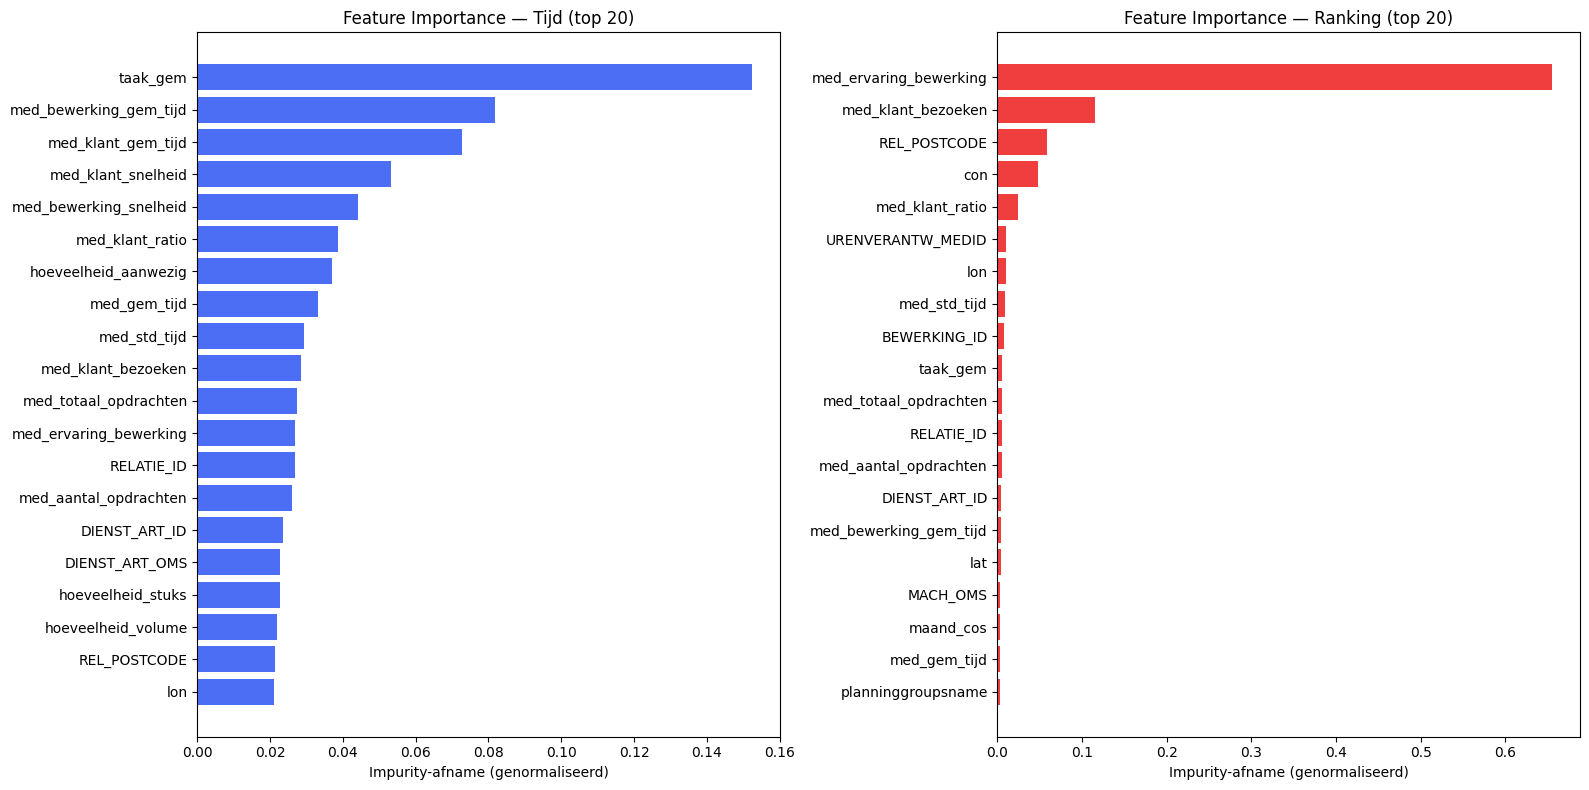

Top 5 regressie features:
taak_gem                  0.152489
med_bewerking_gem_tijd    0.081831
med_klant_gem_tijd        0.072634
med_klant_snelheid        0.053105
med_bewerking_snelheid    0.044015

Top 5 ranking features:
med_ervaring_bewerking    0.655211
med_klant_bezoeken        0.115215
REL_POSTCODE              0.058304
con                       0.047931
med_klant_ratio           0.024417


In [29]:
feature_names = CATEGORICAL + NUMERICAL

reg_imp = pd.Series(reg_model.feature_importances_, index=feature_names).sort_values(
    ascending=False
)
rank_imp = pd.Series(rank_model.feature_importances_, index=feature_names).sort_values(
    ascending=False
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top20_reg = reg_imp.head(20)
axes[0].barh(top20_reg.index[::-1], top20_reg.values[::-1], color="#4c6ef5")
axes[0].set_title("Feature Importance — Tijd (top 20)")
axes[0].set_xlabel("Impurity-afname (genormaliseerd)")

top20_rank = rank_imp.head(20)
axes[1].barh(top20_rank.index[::-1], top20_rank.values[::-1], color="#f03e3e")
axes[1].set_title("Feature Importance — Ranking (top 20)")
axes[1].set_xlabel("Impurity-afname (genormaliseerd)")

plt.tight_layout()
plt.show()

print("Top 5 regressie features:")
print(reg_imp.head(5).to_string())
print("\nTop 5 ranking features:")
print(rank_imp.head(5).to_string())

## Stap 14 — Fine-tuning per database

Voor databases met genoeg data (≥ 500 rijen) train ik een apart model. RF heeft geen `init_model` support zoals LightGBM — ik train een nieuw model per database op de database-specifieke data. Dit is wat duurder maar geeft toch database-specifieke aanpassing.

Dezelfde OrdinalEncoder (gefitst op de volledige traindata) wordt hergebruikt.

In [30]:
DB_KOLOM = "con"
finetuned_reg = {}
finetuned_rank = {}

for db_id in df[DB_KOLOM].unique():
    db_mask = df[DB_KOLOM] == db_id
    db_indices = df.index[db_mask].values

    if len(db_indices) < 500:
        print(f"{db_id}: {len(db_indices)} rijen — te weinig, gebruikt basismodel")
        continue

    tr, va = train_test_split(db_indices, test_size=0.2, random_state=42)

    X_ft_train_rf = np.hstack(
        [enc.transform(df.loc[tr, CATEGORICAL].astype(str)), df.loc[tr, NUMERICAL].values]
    ).astype(np.float32)

    X_ft_val_rf = np.hstack(
        [enc.transform(df.loc[va, CATEGORICAL].astype(str)), df.loc[va, NUMERICAL].values]
    ).astype(np.float32)

    # Regressie fine-tune
    ft_reg = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    ft_reg.fit(X_ft_train_rf, df.loc[tr, TARGET_TIME].values)
    ft_mae = mean_absolute_error(df.loc[va, TARGET_TIME], ft_reg.predict(X_ft_val_rf))
    finetuned_reg[db_id] = ft_reg

    # Ranking fine-tune
    db_sorted = df.loc[db_mask].sort_values("_group_key")
    unique_groups = db_sorted["_group_key"].unique()

    if len(unique_groups) < 5:
        print(
            f"{db_id}: {len(db_indices)} rijen, {len(unique_groups)} groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: {ft_mae:.4f})"
        )
        continue

    ft_rank = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    ft_rank.fit(
        np.hstack(
            [enc.transform(db_sorted[CATEGORICAL].astype(str)), db_sorted[NUMERICAL].values]
        ).astype(np.float32),
        db_sorted[TARGET_RANK].values,
    )
    finetuned_rank[db_id] = ft_rank
    print(f"{db_id}: {len(db_indices)} rijen — fine-tuned, val MAE: {ft_mae:.4f} uur")

print(f"\nFine-tuned regressiemodellen: {len(finetuned_reg)}")
print(f"Fine-tuned rankingmodellen:   {len(finetuned_rank)}")

15_poel: 119 rijen — te weinig, gebruikt basismodel
18_westra: 5 rijen — te weinig, gebruikt basismodel
19_westra: 14 rijen — te weinig, gebruikt basismodel
20_westra: 164 rijen — te weinig, gebruikt basismodel
21_diepen: 521 rijen, 3 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.8759)
21_jennissen: 3790 rijen — fine-tuned, val MAE: 1.5672 uur
21_westra: 196 rijen — te weinig, gebruikt basismodel
21_melse: 30 rijen — te weinig, gebruikt basismodel
22_westra: 209 rijen — te weinig, gebruikt basismodel
22_jennissen: 3807 rijen — fine-tuned, val MAE: 1.7413 uur
22_diepen: 590 rijen, 2 groepen — te weinig groepen voor ranker, alleen regressor fine-tuned (MAE: 0.9911)
24_kuijpers: 147 rijen — te weinig, gebruikt basismodel
25_kuijpers: 118 rijen — te weinig, gebruikt basismodel
22_melse: 33 rijen — te weinig, gebruikt basismodel
23_melse: 42 rijen — te weinig, gebruikt basismodel
22_poel: 5 rijen — te weinig, gebruikt basismodel
23_diepen: 551 rijen, 3 groepen

## Stap 15 — Top-3 hit rate

Hoeveel procent van de gevallen staat de werkelijke medewerker in de top-3 aanbevolen medewerkers?

In [31]:
def bereken_top_k_hit_rate(rank_models, val_idx, df, base_rank_model, enc, k=3, n_samples=500):
    hits, total = 0, 0
    sample_indices = np.random.choice(len(val_idx), min(n_samples, len(val_idx)), replace=False)

    # OrdinalEncoder is op alle categorische features gefit;
    # voor 1 kolom maken we daarom een expliciete mapping.
    urenverantw_idx = CATEGORICAL.index("URENVERANTW_MEDID")
    med_mapping = {str(cat): i for i, cat in enumerate(enc.categories_[urenverantw_idx])}

    for i in sample_indices:
        orig_idx = val_idx[i]
        row = df.iloc[orig_idx]
        db_id = row["con"]
        werkelijke_med = row["URENVERANTW_MEDID"]

        db_mask = df["con"] == db_id
        alle_medewerkers = df.loc[db_mask, "URENVERANTW_MEDID"].unique()
        if len(alle_medewerkers) < 2:
            continue

        ranker = rank_models.get(db_id, base_rank_model)

        # Batch: dezelfde taak-features maar voor elke medewerker
        batch_cat = np.tile(
            enc.transform(pd.DataFrame([row[CATEGORICAL].values], columns=CATEGORICAL).astype(str)),
            (len(alle_medewerkers), 1),
        )

        # Vervang URENVERANTW_MEDID per medewerker met veilige 1-kolom mapping
        med_enc = np.array(
            [med_mapping.get(str(med), -1) for med in alle_medewerkers], dtype=np.float32
        )
        batch_cat[:, urenverantw_idx] = med_enc

        batch_num = np.tile(row[NUMERICAL].values.astype(np.float32), (len(alle_medewerkers), 1))
        batch = np.hstack([batch_cat, batch_num]).astype(np.float32)

        scores = ranker.predict(batch)
        top_k_meds = alle_medewerkers[np.argsort(scores)[-k:]]

        if werkelijke_med in top_k_meds:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0, hits, total


print("Top-3 hit rate berekenen...")
hit_rate, hits, total = bereken_top_k_hit_rate(
    finetuned_rank, val_idx, df, base_rank_model=rank_model, enc=enc
)
print(f"Top-3 hit rate: {hits}/{total} = {hit_rate:.1%}")
print(f"KPI: {'>= 80%' if hit_rate >= 0.80 else '< 80% (onder KPI)'}")

Top-3 hit rate berekenen...


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Do

Top-3 hit rate: 54/499 = 10.8%
KPI: < 80% (onder KPI)


## Stap 16 — End-to-end voorspelling

Ik simuleer hoe de C# API straks werkt: geef een taak mee en krijg een gerankte lijst met medewerkers + geschatte uren terug.

In [32]:
def voorspel_per_medewerker(reg_m, rank_m, taak_row, medewerkers, enc):
    n = len(medewerkers)

    batch_cat = np.tile(
        enc.transform(
            pd.DataFrame([taak_row[CATEGORICAL].values], columns=CATEGORICAL).astype(str)
        ),
        (n, 1),
    )

    urenverantw_idx = CATEGORICAL.index("URENVERANTW_MEDID")
    med_mapping = {str(cat): i for i, cat in enumerate(enc.categories_[urenverantw_idx])}
    med_enc = np.array([med_mapping.get(str(med), -1) for med in medewerkers], dtype=np.float32)
    batch_cat[:, urenverantw_idx] = med_enc

    batch_num = np.tile(taak_row[NUMERICAL].values.astype(np.float32), (n, 1))
    batch = np.hstack([batch_cat, batch_num]).astype(np.float32)

    return (
        pd.DataFrame(
            {
                "medewerker": medewerkers,
                "uren": np.clip(reg_m.predict(batch), 0, None).round(2),
                "geschiktheid": rank_m.predict(batch).round(3),
            }
        )
        .sort_values("geschiktheid", ascending=False)
        .reset_index(drop=True)
    )


# Voorbeeld
val_row_idx = np.random.choice(len(val_idx))
orig_idx = val_idx[val_row_idx]
row = df.iloc[orig_idx]
db_id = row["con"]

alle_meds = df.loc[df["con"] == db_id, "URENVERANTW_MEDID"].unique()
r_model = finetuned_reg.get(db_id, reg_model)
k_model = finetuned_rank.get(db_id, rank_model)

result = voorspel_per_medewerker(r_model, k_model, row, alle_meds, enc)

print(f"Opdracht: index {orig_idx} (database: {db_id})")
print(f"Werkelijke medewerker: {row['URENVERANTW_MEDID']}")
print(f"Werkelijke tijd:       {row[TARGET_TIME]:.2f} uur")
print("\nTop 10 medewerkers:")
print(result.head(10).to_string(index=False))

Opdracht: index 1133 (database: 21_diepen)
Werkelijke medewerker: 16
Werkelijke tijd:       2.00 uur

Top 10 medewerkers:
medewerker  uren  geschiktheid
         9  2.38         0.248
         6  2.28         0.236
        30  2.00         0.235
        16  1.96         0.235
      1003  1.95         0.235
        28  1.96         0.235
      1002  1.95         0.235
         1  1.95         0.235
         5  2.00         0.235
        26  1.96         0.235


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


## Stap 17 — Modellen opslaan

RF modellen worden opgeslagen als `.pkl` via joblib. De OrdinalEncoder bewaar ik ook, want die heeft de C# API nodig voor inference.

In [33]:
os.makedirs("models", exist_ok=True)

joblib.dump(reg_model, "models/rf_regressor.pkl")
joblib.dump(rank_model, "models/rf_ranker.pkl")
joblib.dump(enc, "models/rf_ordinal_encoder.pkl")
print("Basismodellen opgeslagen.")

for db_id, ft_reg in finetuned_reg.items():
    joblib.dump(ft_reg, f"models/rf_regressor_{db_id}.pkl")
    if db_id in finetuned_rank:
        joblib.dump(finetuned_rank[db_id], f"models/rf_ranker_{db_id}.pkl")
        print(f"Fine-tuned: {db_id} (reg + rank)")
    else:
        print(f"Fine-tuned: {db_id} (alleen reg, gebruikt basisranker)")

# Metadata
metadata = {
    "categorical_features": CATEGORICAL,
    "numerical_features": NUMERICAL,
    "all_features": FEATURES,
    "target_time": TARGET_TIME,
    "target_rank": TARGET_RANK,
    "reg_params": {"n_estimators": 200, "max_features": "sqrt"},
    "rank_params": {"n_estimators": 200},
    "finetuned_databases": list(finetuned_reg.keys()),
}
with open("models/rf_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print("Metadata opgeslagen: models/rf_metadata.json")

Basismodellen opgeslagen.
Fine-tuned: 21_diepen (alleen reg, gebruikt basisranker)
Fine-tuned: 21_jennissen (reg + rank)
Fine-tuned: 22_jennissen (reg + rank)
Fine-tuned: 22_diepen (alleen reg, gebruikt basisranker)
Fine-tuned: 23_diepen (alleen reg, gebruikt basisranker)
Fine-tuned: 23_jennissen (reg + rank)
Fine-tuned: 23_hulter (reg + rank)
Fine-tuned: 24_jennissen (reg + rank)
Fine-tuned: 24_hulter (reg + rank)
Fine-tuned: 24_diepen (alleen reg, gebruikt basisranker)
Fine-tuned: 25_hulter (reg + rank)
Fine-tuned: 25_jennissen (reg + rank)
Fine-tuned: 25_diepen (reg + rank)
Fine-tuned: f5ab1b29-de37-4818-bb05-b2fe57ce6768 (reg + rank)
Metadata opgeslagen: models/rf_metadata.json


## Stap 18 — ONNX export

De C# API gebruikt ONNX Runtime. Ik gebruik `skl2onnx` om de sklearn RF te converteren. De OrdinalEncoder mapping sla ik ook op als JSON — zo kan C# de encoding reproduceren zonder Python.

In [34]:
os.makedirs("models_onnx", exist_ok=True)

n_features = X_train_rf.shape[1]
initial_type = [("float_input", FloatTensorType([None, n_features]))]

# Basismodellen
onnx_reg = convert_sklearn(reg_model, initial_types=initial_type)
onnx_rank = convert_sklearn(rank_model, initial_types=initial_type)

with open("models_onnx/rf_regressor.onnx", "wb") as f:
    f.write(onnx_reg.SerializeToString())
with open("models_onnx/rf_ranker.onnx", "wb") as f:
    f.write(onnx_rank.SerializeToString())

print("ONNX export klaar: models_onnx/rf_regressor.onnx, models_onnx/rf_ranker.onnx")

ONNX export klaar: models_onnx/rf_regressor.onnx, models_onnx/rf_ranker.onnx


In [35]:
# Verificatie: sklearn vs ONNX output op 5 validatierijen
test_data = X_val_rf[:5]

sess_reg = ort.InferenceSession("models_onnx/rf_regressor.onnx")
sess_rank = ort.InferenceSession("models_onnx/rf_ranker.onnx")

input_name = sess_reg.get_inputs()[0].name
onnx_reg_out = sess_reg.run(None, {input_name: test_data})[0].flatten()
onnx_rank_out = sess_rank.run(None, {input_name: test_data})[0].flatten()

sklearn_reg_out = reg_model.predict(test_data)
sklearn_rank_out = rank_model.predict(test_data)

print("REGRESSOR — sklearn vs ONNX (5 samples):")
for i in range(5):
    print(f"  {i}: sklearn={sklearn_reg_out[i]:.4f}  ONNX={onnx_reg_out[i]:.4f}")
print(f"Max verschil regressor: {np.max(np.abs(sklearn_reg_out - onnx_reg_out)):.8f}")

print("\nRANKER — sklearn vs ONNX (5 samples):")
for i in range(5):
    print(f"  {i}: sklearn={sklearn_rank_out[i]:.4f}  ONNX={onnx_rank_out[i]:.4f}")
print(f"Max verschil ranker: {np.max(np.abs(sklearn_rank_out - onnx_rank_out)):.8f}")

REGRESSOR — sklearn vs ONNX (5 samples):
  0: sklearn=1.8140  ONNX=1.8140
  1: sklearn=2.9988  ONNX=2.9988
  2: sklearn=3.0109  ONNX=3.0109
  3: sklearn=2.0112  ONNX=2.0113
  4: sklearn=6.0450  ONNX=6.0450
Max verschil regressor: 0.00000111

RANKER — sklearn vs ONNX (5 samples):
  0: sklearn=0.0736  ONNX=0.0736
  1: sklearn=0.2274  ONNX=0.2274
  2: sklearn=0.0233  ONNX=0.0233
  3: sklearn=0.0000  ONNX=0.0000
  4: sklearn=0.0129  ONNX=0.0129
Max verschil ranker: 0.00000015


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 180 tasks      | elapsed:    0.0s
[Parallel(n_jobs=10)]: Done 200 out of 200 | elapsed:    0.0s finished


In [36]:
# OrdinalEncoder mapping opslaan als JSON voor C# API
enc_mapping = {}
for col, categories in zip(CATEGORICAL, enc.categories_):
    enc_mapping[col] = {str(cat): int(i) for i, cat in enumerate(categories)}

with open("models/rf_enc_mapping.json", "w") as f:
    json.dump(enc_mapping, f, indent=2)
print("Encoder mapping opgeslagen: models/rf_enc_mapping.json")

# Fine-tuned modellen naar ONNX
for db_id in finetuned_reg:
    try:
        onnx_ft_reg = convert_sklearn(finetuned_reg[db_id], initial_types=initial_type)
        with open(f"models_onnx/rf_regressor_{db_id}.onnx", "wb") as f:
            f.write(onnx_ft_reg.SerializeToString())

        if db_id in finetuned_rank:
            onnx_ft_rank = convert_sklearn(finetuned_rank[db_id], initial_types=initial_type)
            with open(f"models_onnx/rf_ranker_{db_id}.onnx", "wb") as f:
                f.write(onnx_ft_rank.SerializeToString())
            print(f"  {db_id} -> ONNX OK (reg + rank)")
        else:
            print(f"  {db_id} -> ONNX OK (alleen reg)")
    except Exception as e:
        print(f"  {db_id} -> FOUT: {e}")

Encoder mapping opgeslagen: models/rf_enc_mapping.json
  21_diepen -> ONNX OK (alleen reg)
  21_jennissen -> ONNX OK (reg + rank)
  22_jennissen -> ONNX OK (reg + rank)
  22_diepen -> ONNX OK (alleen reg)
  23_diepen -> ONNX OK (alleen reg)
  23_jennissen -> ONNX OK (reg + rank)
  23_hulter -> ONNX OK (reg + rank)
  24_jennissen -> ONNX OK (reg + rank)
  24_hulter -> ONNX OK (reg + rank)
  24_diepen -> ONNX OK (alleen reg)
  25_hulter -> ONNX OK (reg + rank)
  25_jennissen -> ONNX OK (reg + rank)
  25_diepen -> ONNX OK (reg + rank)
  f5ab1b29-de37-4818-bb05-b2fe57ce6768 -> ONNX OK (reg + rank)


## Stap 19 — MLflow logging

In [37]:
with mlflow.start_run(run_name="random_forest_baseline") as run:
    # Parameters
    mlflow.log_params(
        {
            "reg_n_estimators": 200,
            "reg_max_features": "sqrt",
            "rank_n_estimators": 200,
            "encoder": "OrdinalEncoder",
            "tuning": "none (baseline)",
            "random_state": 42,
        }
    )

    # Metrics
    mlflow.log_metrics(
        {
            "time_mae": mae,
            "time_rmse": rmse,
            "time_r2": r2,
            "ndcg_at_3": mean_ndcg3,
            "ndcg_at_5": mean_ndcg5,
            "top3_hit_rate": hit_rate,
            "dataset_rows": len(df),
        }
    )

    # ONNX modellen
    for path, artifact_path in [
        ("models_onnx/rf_regressor.onnx", "onnx"),
        ("models_onnx/rf_ranker.onnx", "onnx"),
        ("models/rf_metadata.json", None),
        ("models/rf_enc_mapping.json", "artifacts"),
        ("models/rf_ordinal_encoder.pkl", "artifacts"),
    ]:
        if os.path.exists(path):
            mlflow.log_artifact(
                path, **(({"artifact_path": artifact_path}) if artifact_path else {})
            )

    run_id = run.info.run_id
    print(f"MLflow run ID: {run_id}")
    print(f"Experiment:    {MLFLOW_EXPERIMENT}")

# Fine-tuned ONNX modellen loggen
with mlflow.start_run(run_id=run_id):
    logged = 0
    for db_id in finetuned_reg:
        reg_path = f"models_onnx/rf_regressor_{db_id}.onnx"
        rank_path = f"models_onnx/rf_ranker_{db_id}.onnx"
        if os.path.exists(reg_path):
            mlflow.log_artifact(reg_path, artifact_path=f"finetuned/{db_id}")
            logged += 1
        if os.path.exists(rank_path):
            mlflow.log_artifact(rank_path, artifact_path=f"finetuned/{db_id}")
    print(f"Fine-tuned modellen gelogd voor {logged} databases")

MLflow run ID: 6b137d79a65d47a1b44d211612faa020
Experiment:    rister-random-forest-v1
🏃 View run random_forest_baseline at: http://127.0.0.1:5002/#/experiments/6/runs/6b137d79a65d47a1b44d211612faa020
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/6
Fine-tuned modellen gelogd voor 14 databases
🏃 View run random_forest_baseline at: http://127.0.0.1:5002/#/experiments/6/runs/6b137d79a65d47a1b44d211612faa020
🧪 View experiment at: http://127.0.0.1:5002/#/experiments/6


In [40]:
# Model registry: registreer als MAE beter is dan huidige beste
client = MlflowClient()


def get_best_registry_mae(model_name):
    try:
        versions = client.search_model_versions(f"name='{model_name}'")
        maes = []
        for v in versions:
            metrics = client.get_run(v.run_id).data.metrics
            if "time_mae" in metrics:
                maes.append(metrics["time_mae"])
        return min(maes) if maes else float("inf")
    except Exception:
        return float("inf")


def ensure_registered_model(model_name):
    try:
        client.get_registered_model(model_name)
    except Exception:
        client.create_registered_model(model_name)
        print(f"Registered model aangemaakt: {model_name}")


def register_onnx_artifact_version(run_id, artifact_path, model_name):
    ensure_registered_model(model_name)
    source_uri = f"runs:/{run_id}/{artifact_path}"
    mv = client.create_model_version(
        name=model_name,
        source=source_uri,
        run_id=run_id,
    )
    print(f"Geregistreerd: {model_name} v{mv.version} vanuit {source_uri}")


best_mae_registry = get_best_registry_mae("rister-rf-regressor")

if mae < best_mae_registry:
    register_onnx_artifact_version(run_id, "onnx/rf_regressor.onnx", "rister-rf-regressor")
    register_onnx_artifact_version(run_id, "onnx/rf_ranker.onnx", "rister-rf-ranker")
    print(f"Nieuwe beste versie geregistreerd! MAE: {mae:.4f} (was: {best_mae_registry:.4f})")
else:
    print(
        f"Niet geregistreerd - MAE ({mae:.4f}) is niet beter dan registry ({best_mae_registry:.4f})"
    )

Niet geregistreerd - MAE (1.4932) is niet beter dan registry (1.4932)


## Stap 20 — Conclusie

### Resultaten

| Model | MAE (uur) | NDCG@3 |ONNX stabiel | Complexiteit |
|-------|-----------|--------|--------------|--------------|
| LightGBM | 1.2490 | 0.9541 | Ja | Laag |
| Random Forest | 1.4932 | 0.9582 | Ja | Laag |

### Wat ik hieruit leer

Random Forest is de baseline — geen hyperparameter tuning, vaste instellingen. De twee belangrijkste observaties:

1. **Regressie**: RF (MAE 1.49 uur) scoort duidelijk slechter dan LightGBM (MAE 1.25 uur, verschil +0.24 uur). LightGBM-tuning voegt dus echte waarde toe voor tijdsvoorspelling.

2. **Ranking**: RF haalt een NDCG@3 van 0.9582, bijna gelijk aan LightGBM (0.9541). De keuze voor LambdaRank in LightGBM maakt op ranking weinig verschil — de pointwise aanpak werkt al goed voor deze dataset.

### Vergelijking met LightGBM

- **MAE**: LightGBM 1.2490 uur vs RF 1.4932 uur — LightGBM is 0.24 uur beter (16% verbetering)
- **NDCG@3**: LightGBM 0.9541 vs RF 0.9582 — vrijwel gelijk, RF is marginaal hoger
- **Top-3 hit rate**: RF 10.8% — LightGBM referentie nog niet beschikbaar

Beide modellen halen de KPIs (MAE ≤ 0.5 uur, NDCG@3 ≥ 0.80) niet op MAE — dat is verwacht voor deze complexe dataset. Op ranking halen beide modellen de KPI wél (NDCG@3 ≥ 0.80). De hoofdconclusie: LightGBM heeft meerwaarde op regressie, maar niet op ranking.